c:\Users\ketan\.local\share\mamba\envs\climada_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RH range (historical): 1.834578037261963 105.0
RH range (future, raw): 1.8086209297180176 105.0
RH range (future, clipped): 1.8086209297180176 100.0
Historical days > 35°C WBT (India mean): 0.01 days/year
Future days > 35°C WBT     (India mean): 0.08 days/year
Change (India mean)                      : +0.07 days/year

=== BASIC SHAPES ===
Tw_370 shape: (31046, 600, 1440)
fut_days_35 shape: (85, 600, 1440)
Unique future years: [2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029
 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043
 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057
 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071
 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085
 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099
 2100]

=== GRIDCELL STATISTICS (Future WBT > 35°C) ===
Min: 0.0
Max: 114.04705882352941
Mean over India: 0.075904193899782

=== NaN CHECK ===


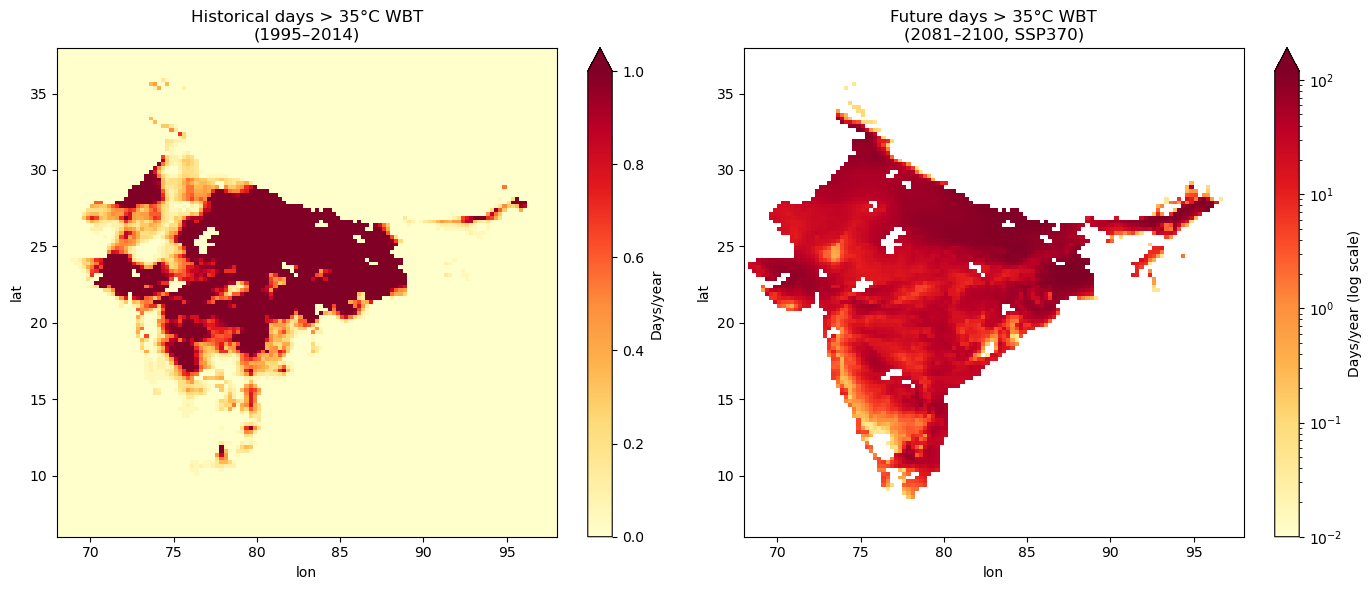

Historical 1995 done
Historical 1996 done
Historical 1997 done
Historical 1998 done
Historical 1999 done
Historical 2000 done
Historical 2001 done
Historical 2002 done
Historical 2003 done
Historical 2004 done
Historical 2005 done
Historical 2006 done
Historical 2007 done
Historical 2008 done
Historical 2009 done
Historical 2010 done
Historical 2011 done
Historical 2012 done
Historical 2013 done
Historical 2014 done
Future 2016 done
Future 2017 done
Future 2018 done
Future 2019 done
Future 2020 done
Future 2021 done
Future 2022 done
Future 2023 done
Future 2024 done
Future 2025 done
Future 2026 done
Future 2027 done
Future 2028 done
Future 2029 done
Future 2030 done
Future 2031 done
Future 2032 done
Future 2033 done
Future 2034 done
Future 2035 done
Future 2036 done
Future 2037 done
Future 2038 done
Future 2039 done
Future 2040 done
Future 2041 done
Future 2042 done
Future 2043 done
Future 2044 done
Future 2045 done
Future 2046 done
Future 2047 done
Future 2048 done
Future 2049 done
Fu

c:\Users\ketan\.local\share\mamba\envs\climada_env\lib\site-packages\dask\array\reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


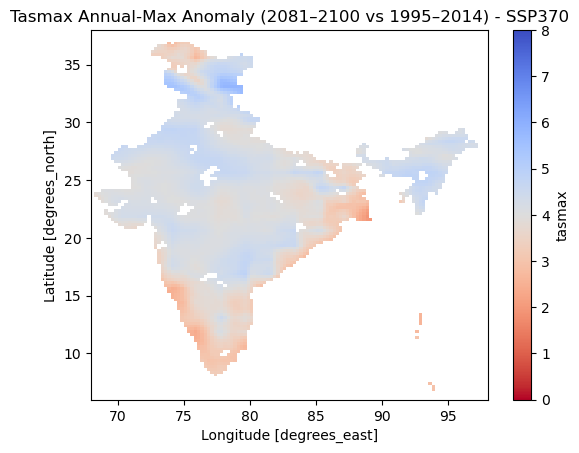

Historical WBT>35: {'mean_days': 0.0073248263888888955, '>0': 0.36250000000000004, '>1': 0.17777777777777778, '>5': 0.043402777777777776, '>10': 0.007523148148148149, 'max': 20.25}
Near-term WBT>35: {'mean_days': 0.023325587606837634, '>0': 0.3887731481481482, '>1': 0.3111111111111111, '>5': 0.16736111111111113, '>10': 0.0724537037037037, 'max': 67.61538461538461}
Mid-century WBT>35: {'mean_days': 0.04511292438271596, '>0': 0.4295138888888889, '>1': 0.37546296296296294, '>5': 0.26840277777777777, '>10': 0.15810185185185185, 'max': 109.56666666666666}
End-century WBT>35: {'mean_days': 0.17109803240740754, '>0': 0.44699074074074074, '>1': 0.4248842592592592, '>5': 0.3914351851851852, '>10': 0.36365740740740743, 'max': 173.5}

=== Historical (1995–2014) ===
Max days/year: 20.25
Gridcells >0 days/year : 0.363%
Gridcells >1 day/year  : 0.178%
Gridcells >5 days/year : 0.043%
Gridcells >10 days/year: 0.008%

=== Near-term (2027–2039) ===
Max days/year: 67.62
Gridcells >0 days/year : 0.389%
Gr

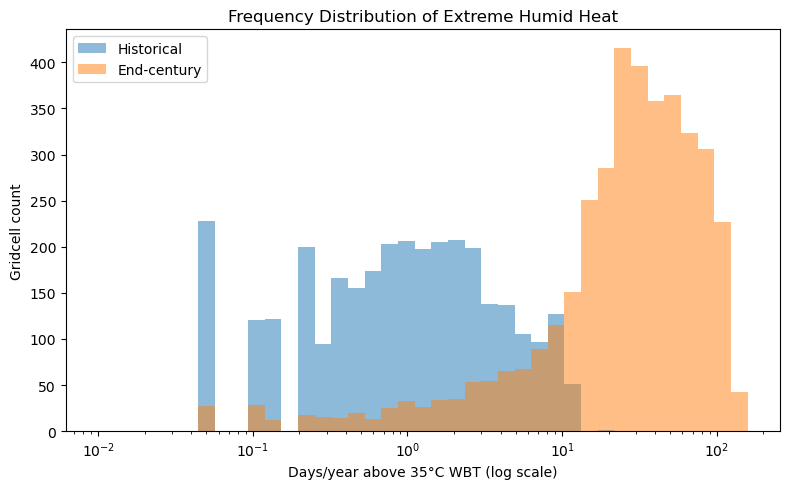

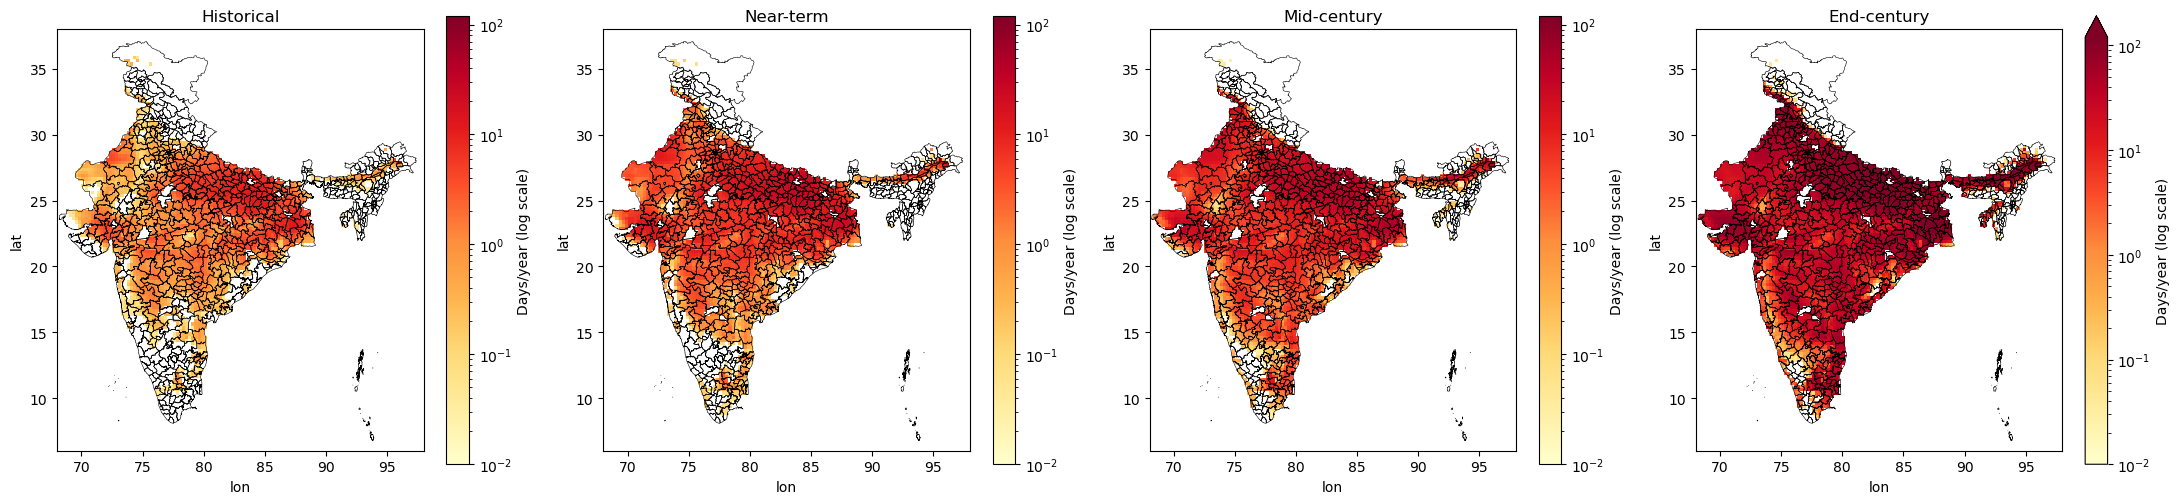

In [1]:
# ⭐ 1. Imports & Paths

import xarray as xr
import geopandas as gpd
import regionmask
import rioxarray
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors  # for LogNorm

DATA = Path("E:/Heat/Data")


# ⭐ 2. Load India boundary + regionmask

INDIA = gpd.read_file(
    r"C:\CMIP_data\cmip6\Climada\Projects\ccart-india\ccart\data\boundaries\INDIA_DISTRICTS_FIXED.gpkg"
).to_crs("EPSG:4326")

RM_INDIA = regionmask.Regions(
    outlines=INDIA.geometry.values,
    names=INDIA["district"].tolist(),
    numbers=list(range(len(INDIA))),
    abbrevs=INDIA["statecode"].tolist(),
    overlap=True
)


# ⭐ 3. Reusable loader (multi‑file + clip)

def load_and_clip(files):
    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        engine="h5netcdf",
        chunks={"time": 365}
    )
    mask3D = RM_INDIA.mask_3D(ds)
    mask2D = mask3D.any("region")
    return ds.where(mask2D)


# ⭐ 4. Simple mean climatology (kept for possible future use)

def climatology(ds, var, start, end):
    period = ds[var].sel(time=slice(start, end))
    return period.mean("time").load()


# ⭐ 4b. Stull Wet‑Bulb Temperature (2011)

def wet_bulb_temperature_stull(T_c, RH):
    Tw = (T_c * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T_c + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw


def wet_bulb_stull_xr(T_c, RH):
    return xr.apply_ufunc(
        wet_bulb_temperature_stull,
        T_c,
        RH,
        input_core_dims=[[], []],
        dask="parallelized",
        output_dtypes=[float],
    )


# ⭐ 5. Load historical datasets (tasmax + hurs)

hist_tasmax_files = sorted((DATA / "historical" / "tasmax").glob("tasmax_day_ACCESS-CM2_historical_*.nc"))
hist_hurs_files   = sorted((DATA / "historical" / "hurs").glob("hurs_day_ACCESS-CM2_historical_*.nc"))

ds_hist_tasmax = load_and_clip(hist_tasmax_files)
ds_hist_hurs   = load_and_clip(hist_hurs_files)

# ⭐ Correct RH logic (historical)
rh_min = float(ds_hist_hurs["hurs"].min())
rh_max = float(ds_hist_hurs["hurs"].max())
print("RH range (historical):", rh_min, rh_max)

if rh_max <= 1.5:
    print("Converting historical RH from fraction to %")
    ds_hist_hurs["hurs"] *= 100

ds_hist_hurs["hurs"] = ds_hist_hurs["hurs"].clip(0, 100)


# ⭐ 6. Load SSP370 datasets (tasmax + hurs)

ssp370_tasmax_files = sorted((DATA / "ssp370" / "tasmax").glob("tasmax_day_ACCESS-CM2_ssp370_*.nc"))
ssp370_hurs_files   = sorted((DATA / "ssp370" / "hurs").glob("hurs_day_ACCESS-CM2_ssp370_*.nc"))

ds_370_tasmax = load_and_clip(ssp370_tasmax_files)
ds_370_hurs   = load_and_clip(ssp370_hurs_files)

# ⭐ Correct RH logic (future)
rh_min = float(ds_370_hurs["hurs"].min())
rh_max = float(ds_370_hurs["hurs"].max())
print("RH range (future, raw):", rh_min, rh_max)

if rh_max <= 1.5:
    print("Converting future RH from fraction to %")
    ds_370_hurs["hurs"] *= 100

ds_370_hurs["hurs"] = ds_370_hurs["hurs"].clip(0, 100)

print("RH range (future, clipped):",
      float(ds_370_hurs["hurs"].min()),
      float(ds_370_hurs["hurs"].max()))


# ⭐ 8. Annual‑max climatology (heat‑relevant) for tasmax

def annual_max_climatology(ds, var, start, end):
    period = ds[var].sel(time=slice(start, end))
    annual_max = period.groupby("time.year").max("time")
    return annual_max.mean("year").load()


# ⭐ 9. Compute baseline & future tasmax climatology (annual max)

baseline_tasmax = annual_max_climatology(ds_hist_tasmax, "tasmax", "1995-01-01", "2014-12-31")
future370_tasmax = annual_max_climatology(ds_370_tasmax, "tasmax", "2081-01-01", "2100-12-31")


# ⭐ 10. Compute tasmax anomaly (in °C)

baseline_tasmax_C = baseline_tasmax - 273.15
future370_tasmax_C = future370_tasmax - 273.15

tasmax_anomaly_370 = future370_tasmax_C - baseline_tasmax_C


# ⭐ 11. Compute WBT (full time series) — with time alignment

common_time_hist = np.intersect1d(ds_hist_tasmax.time.values, ds_hist_hurs.time.values)
T_hist = ds_hist_tasmax["tasmax"].sel(time=common_time_hist) - 273.15
RH_hist = ds_hist_hurs["hurs"].sel(time=common_time_hist)
Tw_hist = wet_bulb_stull_xr(T_hist, RH_hist)

common_time_370 = np.intersect1d(ds_370_tasmax.time.values, ds_370_hurs.time.values)
T_370 = ds_370_tasmax["tasmax"].sel(time=common_time_370) - 273.15
RH_370 = ds_370_hurs["hurs"].sel(time=common_time_370)
Tw_370 = wet_bulb_stull_xr(T_370, RH_370)


# ⭐ 12. Memory‑safe days above 35°C WBT per year

years_hist = np.unique(Tw_hist["time.year"])
hist_days_35_list = []
for y in years_hist:
    days = (Tw_hist.sel(time=str(y)) > 35).sum("time").load()
    days = days.assign_coords(year=y)
    hist_days_35_list.append(days)
hist_days_35 = xr.concat(hist_days_35_list, dim="year")

years_future = np.unique(Tw_370["time.year"])
fut_days_35_list = []
for y in years_future:
    days = (Tw_370.sel(time=str(y)) > 35).sum("time").load()
    days = days.assign_coords(year=y)
    fut_days_35_list.append(days)
fut_days_35 = xr.concat(fut_days_35_list, dim="year")

# India‑wide mean (kept, but we know it downplays risk)
print(f"Historical days > 35°C WBT (India mean): {float(hist_days_35.mean()):.2f} days/year")
print(f"Future days > 35°C WBT     (India mean): {float(fut_days_35.mean()):.2f} days/year")
print(f"Change (India mean)                      : +{float(fut_days_35.mean() - hist_days_35.mean()):.2f} days/year")


# ============================================================
# ⭐ DIAGNOSTICS: Validate WBT > 35°C maps and dataset integrity
# ============================================================

print("\n=== BASIC SHAPES ===")
print("Tw_370 shape:", Tw_370.shape)
print("fut_days_35 shape:", fut_days_35.shape)
print("Unique future years:", years_future)

# Mean over years (per-gridcell) → frequency (days/year) at each gridcell
m = fut_days_35.mean("year")

print("\n=== GRIDCELL STATISTICS (Future WBT > 35°C) ===")
print("Min:", float(m.min()))
print("Max:", float(m.max()))
print("Mean over India:", float(m.mean()))

print("\n=== NaN CHECK ===")
print("Any NaNs in m:", np.isnan(m.values).sum())

vals = m.values.flatten()

print("\n=== DISTRIBUTION CHECK (frequency classes, days/year) ===")
print("Gridcells == 0 days/year:", np.sum(vals == 0))
print("Gridcells > 0 days/year :", np.sum(vals > 0))
print("Gridcells > 1 day/year  :", np.sum(vals > 1))
print("Gridcells > 5 days/year :", np.sum(vals > 5))
print("Gridcells > 10 days/year:", np.sum(vals > 10))

total_cells = vals.size
for thr in [0, 1, 5, 10]:
    frac = np.sum(vals > thr) / total_cells * 100
    print(f"Fraction of gridcells with > {thr} days/year: {frac:.3f}%")


# ⭐ 13. Spatial maps (log scale for future)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Historical (linear, low values)
hist_days_35.mean("year").plot(
    ax=axes[0],
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Days/year"}
)
axes[0].set_title("Historical days > 35°C WBT\n(1995–2014)")
axes[0].set_xlim(68, 98); axes[0].set_ylim(6, 38)

# Future (log scale to reveal tail)
m_future = fut_days_35.sel(year=slice(2081, 2100)).mean("year")
m_future_plot = m_future.where(m_future > 0)  # avoid log(0)

m_future_plot.plot(
    ax=axes[1],
    cmap="YlOrRd",
    norm=colors.LogNorm(vmin=0.01, vmax=120),
    cbar_kwargs={"label": "Days/year (log scale)"}
)
axes[1].set_title("Future days > 35°C WBT\n(2081–2100, SSP370)")
axes[1].set_xlim(68, 98); axes[1].set_ylim(6, 38)

plt.tight_layout()
plt.savefig("wbt35_comparison_logscale.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# ⭐ 14. Threshold diagnostics — TIME-SLICED + FREQUENCY-GRADE
# ============================================================

thresholds = [28, 30, 32, 35]
threshold_stacks = {th: {"hist": [], "fut": []} for th in thresholds}

# Historical
for y in years_hist:
    tw_y = Tw_hist.sel(time=str(y))
    for th in thresholds:
        days = (tw_y > th).sum("time").load()
        days = days.assign_coords(year=y)
        threshold_stacks[th]["hist"].append(days)
    print(f"Historical {y} done")

# Future
for y in years_future:
    tw_y = Tw_370.sel(time=str(y))
    for th in thresholds:
        days = (tw_y > th).sum("time").load()
        days = days.assign_coords(year=y)
        threshold_stacks[th]["fut"].append(days)
    print(f"Future {y} done")

# Concat
for th in thresholds:
    threshold_stacks[th]["hist"] = xr.concat(threshold_stacks[th]["hist"], dim="year")
    threshold_stacks[th]["fut"]  = xr.concat(threshold_stacks[th]["fut"],  dim="year")


# ⭐ Frequency stats helper

def freq_stats(arr):
    vals = arr.values.flatten()
    vals = vals[~np.isnan(vals)]
    total = vals.size
    return {
        "mean_days": float(arr.mean()),
        ">0":  np.sum(vals > 0)  / total * 100,
        ">1":  np.sum(vals > 1)  / total * 100,
        ">5":  np.sum(vals > 5)  / total * 100,
        ">10": np.sum(vals > 10) / total * 100,
        "max": float(vals.max())
    }


# ⭐ PRINT RESULTS FOR EACH THRESHOLD

for thresh in thresholds:
    hist_mean_th = threshold_stacks[thresh]["hist"].mean("year")
    near_th      = threshold_stacks[thresh]["fut"].sel(year=slice(2027, 2039)).mean("year")
    mid_th       = threshold_stacks[thresh]["fut"].sel(year=slice(2040, 2069)).mean("year")
    end_th       = threshold_stacks[thresh]["fut"].sel(year=slice(2081, 2100)).mean("year")

    hist_s = freq_stats(hist_mean_th)
    near_s = freq_stats(near_th)
    mid_s  = freq_stats(mid_th)
    end_s  = freq_stats(end_th)

    print(f"\n==================== WBT > {thresh}°C ====================")

    print("\nHistorical (1995–2014):")
    print(f"  Mean days/year: {hist_s['mean_days']:.2f}")
    print(f"  Gridcells >0 days/year : {hist_s['>0']:.3f}%")
    print(f"  Gridcells >1 day/year  : {hist_s['>1']:.3f}%")
    print(f"  Gridcells >5 days/year : {hist_s['>5']:.3f}%")
    print(f"  Gridcells >10 days/year: {hist_s['>10']:.3f}%")
    print(f"  Max days/year: {hist_s['max']:.2f}")

    print("\nNear-term (2027–2039):")
    print(f"  Mean days/year: {near_s['mean_days']:.2f}")
    print(f"  Gridcells >0 days/year : {near_s['>0']:.3f}%")
    print(f"  Gridcells >1 day/year  : {near_s['>1']:.3f}%")
    print(f"  Gridcells >5 days/year : {near_s['>5']:.3f}%")
    print(f"  Gridcells >10 days/year: {near_s['>10']:.3f}%")
    print(f"  Max days/year: {near_s['max']:.2f}")

    print("\nMid-century (2040–2069):")
    print(f"  Mean days/year: {mid_s['mean_days']:.2f}")
    print(f"  Gridcells >0 days/year : {mid_s['>0']:.3f}%")
    print(f"  Gridcells >1 day/year  : {mid_s['>1']:.3f}%")
    print(f"  Gridcells >5 days/year : {mid_s['>5']:.3f}%")
    print(f"  Gridcells >10 days/year: {mid_s['>10']:.3f}%")
    print(f"  Max days/year: {mid_s['max']:.2f}")

    print("\nEnd-century (2081–2100):")
    print(f"  Mean days/year: {end_s['mean_days']:.2f}")
    print(f"  Gridcells >0 days/year : {end_s['>0']:.3f}%")
    print(f"  Gridcells >1 day/year  : {end_s['>1']:.3f}%")
    print(f"  Gridcells >5 days/year : {end_s['>5']:.3f}%")
    print(f"  Gridcells >10 days/year: {end_s['>10']:.3f}%")
    print(f"  Max days/year: {end_s['max']:.2f}")


# ⭐ 15. Memory‑safe annual‑max WBT climatology

hist_max_list = []
for y in years_hist:
    max_y = Tw_hist.sel(time=str(y)).max("time").load()
    max_y = max_y.assign_coords(year=y)
    hist_max_list.append(max_y)
Tw_hist_annual_max = xr.concat(hist_max_list, dim="year")
Tw_hist_clim = Tw_hist_annual_max.mean("year")

fut_max_list = []
for y in years_future:
    max_y = Tw_370.sel(time=str(y)).max("time").load()
    max_y = max_y.assign_coords(year=y)
    fut_max_list.append(max_y)
Tw_370_annual_max = xr.concat(fut_max_list, dim="year")
Tw_370_clim = Tw_370_annual_max.mean("year")

Tw_anomaly_370 = Tw_370_clim - Tw_hist_clim


# ⭐ 16. Darker, clearer tasmax anomaly plot

tasmax_anomaly_370.plot(
    cmap="coolwarm_r",
    vmin=0,
    vmax=8
)
plt.title("Tasmax Annual-Max Anomaly (2081–2100 vs 1995–2014) - SSP370")
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.show()


# ============================================================
# ⭐ POLICY-GRADE FREQUENCY ANALYSIS (Near/Mid/End Century)
# ============================================================

def frequency_summary(ds, label):
    vals = ds.values.flatten()
    total = vals.size
    return {
        "label": label,
        ">0":  np.sum(vals > 0)  / total * 100,
        ">1":  np.sum(vals > 1)  / total * 100,
        ">5":  np.sum(vals > 5)  / total * 100,
        ">10": np.sum(vals > 10) / total * 100,
        "max": float(vals.max())
    }

hist_35 = threshold_stacks[35]["hist"].mean("year")
near_35 = threshold_stacks[35]["fut"].sel(year=slice(2027, 2039)).mean("year")
mid_35  = threshold_stacks[35]["fut"].sel(year=slice(2040, 2069)).mean("year")
end_35  = threshold_stacks[35]["fut"].sel(year=slice(2081, 2100)).mean("year")

print("Historical WBT>35:", freq_stats(hist_35))
print("Near-term WBT>35:", freq_stats(near_35))
print("Mid-century WBT>35:", freq_stats(mid_35))
print("End-century WBT>35:", freq_stats(end_35))


# ⭐ Time slices for WBT>35 hazard rasters

hist_mean = hist_days_35.mean("year")
near  = fut_days_35.sel(year=slice(2027, 2039)).mean("year")
mid   = fut_days_35.sel(year=slice(2040, 2069)).mean("year")
endc  = fut_days_35.sel(year=slice(2081, 2100)).mean("year")

OUT = Path(r"C:\CMIP_data\cmip6\Climada\Projects\ccart-india\ccart\Heat\outputs")
OUT.mkdir(parents=True, exist_ok=True)

for ds, fname in [
    (hist_mean, OUT / "CCART_Hazard_WBT35_Historical_1995-2014.tif"),
    (near,      OUT / "CCART_Hazard_WBT35_NearTerm_2027-2039.tif"),
    (mid,       OUT / "CCART_Hazard_WBT35_MidCentury_2040-2069.tif"),
    (endc,      OUT / "CCART_Hazard_WBT35_EndCentury_2081-2100.tif"),
]:
    ds_r = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    ds_r = ds_r.rio.write_crs("EPSG:4326", inplace=False)
    ds_r.rio.to_raster(fname, compress="LZW")


# ⭐ Print frequency summaries for WBT>35 hazard rasters

for ds, label in [
    (hist_mean, "Historical (1995–2014)"),
    (near,      "Near-term (2027–2039)"),
    (mid,       "Mid-century (2040–2069)"),
    (endc,      "End-century (2081–2100)")
]:
    f = frequency_summary(ds, label)
    print(f"\n=== {label} ===")
    print(f"Max days/year: {f['max']:.2f}")
    print(f"Gridcells >0 days/year : {f['>0']:.3f}%")
    print(f"Gridcells >1 day/year  : {f['>1']:.3f}%")
    print(f"Gridcells >5 days/year : {f['>5']:.3f}%")
    print(f"Gridcells >10 days/year: {f['>10']:.3f}%")


# ============================================================
# ⭐ HISTOGRAMS (log-scale bins)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

bins = np.logspace(-2, 2.2, 40)  # 0.01 → ~160 days/year

hist_vals = hist_mean.values.flatten()
endc_vals = endc.values.flatten()

hist_vals = hist_vals[hist_vals > 0]
endc_vals = endc_vals[endc_vals > 0]

ax.hist(hist_vals, bins=bins, alpha=0.5, label="Historical")
ax.hist(endc_vals, bins=bins, alpha=0.5, label="End-century")

ax.set_xscale("log")
ax.set_xlabel("Days/year above 35°C WBT (log scale)")
ax.set_ylabel("Gridcell count")
ax.set_title("Frequency Distribution of Extreme Humid Heat")
ax.legend()

plt.tight_layout()
plt.savefig("wbt35_histograms.png", dpi=150)
plt.show()


# ============================================================
# ⭐ MAPS (Historical vs Near/Mid/End Century)
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

datasets = [
    (hist_mean, "Historical"),
    (near,      "Near-term"),
    (mid,       "Mid-century"),
    (endc,      "End-century")
]

for ax, (ds, title) in zip(axes, datasets):
    ds_plot = ds.where(ds > 0)
    ds_plot.plot(
        ax=ax,
        cmap="YlOrRd",
        norm=colors.LogNorm(vmin=0.01, vmax=120),
        cbar_kwargs={"label": "Days/year (log scale)"}
    )
    INDIA.boundary.plot(ax=ax, color="black", linewidth=0.4, zorder=3)
    ax.set_title(title)
    ax.set_xlim(68, 98)
    ax.set_ylim(6, 38)

plt.tight_layout()
plt.savefig("wbt35_timeslices_logscale.png", dpi=150)
plt.show()

